In [22]:
# Célula 1: Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from collections import Counter
from tabulate import tabulate
import joblib
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("🎯 PREPARAÇÃO FINAL - SPLIT E BALANCEAMENTO")
print("=" * 80)

🎯 PREPARAÇÃO FINAL - SPLIT E BALANCEAMENTO


In [5]:
# Célula 2: Carregar Dados Selecionados
print("\n" + "=" * 80)
print("📊 CARREGANDO DADOS COM FEATURES SELECIONADAS")
print("=" * 80)

# Carregar as 3 versões
datasets = {}
for version in ['no_scale', 'standardized', 'normalized']:
    filepath = f'../data/processed_data/data_{version}_selected.csv'
    datasets[version] = pd.read_csv(filepath)
    print(f"✅ {version:15s}: {datasets[version].shape}")

target_col = 'inadipl_90dias_ult2anos'


📊 CARREGANDO DADOS COM FEATURES SELECIONADAS
✅ no_scale       : (149234, 29)
✅ standardized   : (149234, 29)
✅ normalized     : (149234, 29)


In [6]:
# Célula 3: Train/Test Split
print("\n" + "=" * 80)
print("✂️ TRAIN/TEST SPLIT")
print("=" * 80)

# Usar stratify para manter proporção de classes
test_size = 0.2
random_state = 42

print(f"\n📊 Configuração:")
print(f"   Test size: {test_size*100:.0f}%")
print(f"   Random state: {random_state}")
print(f"   Stratified: Sim")

# Fazer split para cada versão
splits = {}

for version, df in datasets.items():
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    
    splits[version] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }
    
    print(f"\n✅ {version}:")
    print(f"   Train: {X_train.shape}")
    print(f"   Test:  {X_test.shape}")
    print(f"   Proporção train/test: {len(X_train)}/{len(X_test)}")

# Verificar distribuição de classes
print(f"\n📊 Distribuição de Classes:")
for version in splits.keys():
    y_train = splits[version]['y_train']
    y_test = splits[version]['y_test']
    
    print(f"\n{version}:")
    print(f"  Train - Bons: {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
    print(f"         Maus:  {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")
    print(f"  Test  - Bons: {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")
    print(f"         Maus:  {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")


✂️ TRAIN/TEST SPLIT

📊 Configuração:
   Test size: 20%
   Random state: 42
   Stratified: Sim

✅ no_scale:
   Train: (119387, 28)
   Test:  (29847, 28)
   Proporção train/test: 119387/29847

✅ standardized:
   Train: (119387, 28)
   Test:  (29847, 28)
   Proporção train/test: 119387/29847

✅ normalized:
   Train: (119387, 28)
   Test:  (29847, 28)
   Proporção train/test: 119387/29847

📊 Distribuição de Classes:

no_scale:
  Train - Bons: 111381 (93.3%)
         Maus:  8006 (6.7%)
  Test  - Bons: 27845 (93.3%)
         Maus:  2002 (6.7%)

standardized:
  Train - Bons: 111381 (93.3%)
         Maus:  8006 (6.7%)
  Test  - Bons: 27845 (93.3%)
         Maus:  2002 (6.7%)

normalized:
  Train - Bons: 111381 (93.3%)
         Maus:  8006 (6.7%)
  Test  - Bons: 27845 (93.3%)
         Maus:  2002 (6.7%)


In [14]:
print("\n" + "=" * 80)
print("⚖️ BALANCEAMENTO COM SMOTE")
print("=" * 80)

print("\n⚠️ IMPORTANTE: SMOTE aplicado APENAS no conjunto de TREINO")
print("   (Nunca aplicar no teste - causaria data leakage!)")

# Aplicar SMOTE para cada versão
splits_balanced = {}

for version in splits.keys():
    print(f"\n🔄 Aplicando SMOTE em {version}...")
    
    X_train = splits[version]['X_train']
    y_train = splits[version]['y_train']
    X_test = splits[version]['X_test']
    y_test = splits[version]['y_test']
    
    # Imputação de valores ausentes (mediana para numéricas)
    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)
    
    # Distribuição antes
    print(f"   Antes:  {Counter(y_train)}")
    
    # Aplicar SMOTE
    smote = SMOTE(random_state=random_state)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    
    # Distribuição depois
    print(f"   Depois: {Counter(y_train_balanced)}")
    print(f"   Aumento: {len(X_train)} → {len(X_train_balanced)} samples")
    
    splits_balanced[version] = {
        'X_train': X_train_balanced,
        'X_test': X_test,
        'y_train': y_train_balanced,
        'y_test': y_test
    }
    
    print(f"   ✅ Train balanceado: {X_train_balanced.shape}")
    print(f"   ✅ Test original: {X_test.shape}")



⚖️ BALANCEAMENTO COM SMOTE

⚠️ IMPORTANTE: SMOTE aplicado APENAS no conjunto de TREINO
   (Nunca aplicar no teste - causaria data leakage!)

🔄 Aplicando SMOTE em no_scale...
   Antes:  Counter({False: 111381, True: 8006})
   Depois: Counter({False: 111381, True: 111381})
   Aumento: 119387 → 222762 samples
   ✅ Train balanceado: (222762, 28)
   ✅ Test original: (29847, 28)

🔄 Aplicando SMOTE em standardized...
   Antes:  Counter({False: 111381, True: 8006})
   Depois: Counter({False: 111381, True: 111381})
   Aumento: 119387 → 222762 samples
   ✅ Train balanceado: (222762, 28)
   ✅ Test original: (29847, 28)

🔄 Aplicando SMOTE em normalized...
   Antes:  Counter({False: 111381, True: 8006})
   Depois: Counter({False: 111381, True: 111381})
   Aumento: 119387 → 222762 samples
   ✅ Train balanceado: (222762, 28)
   ✅ Test original: (29847, 28)



📊 VISUALIZAÇÃO DO BALANCEAMENTO


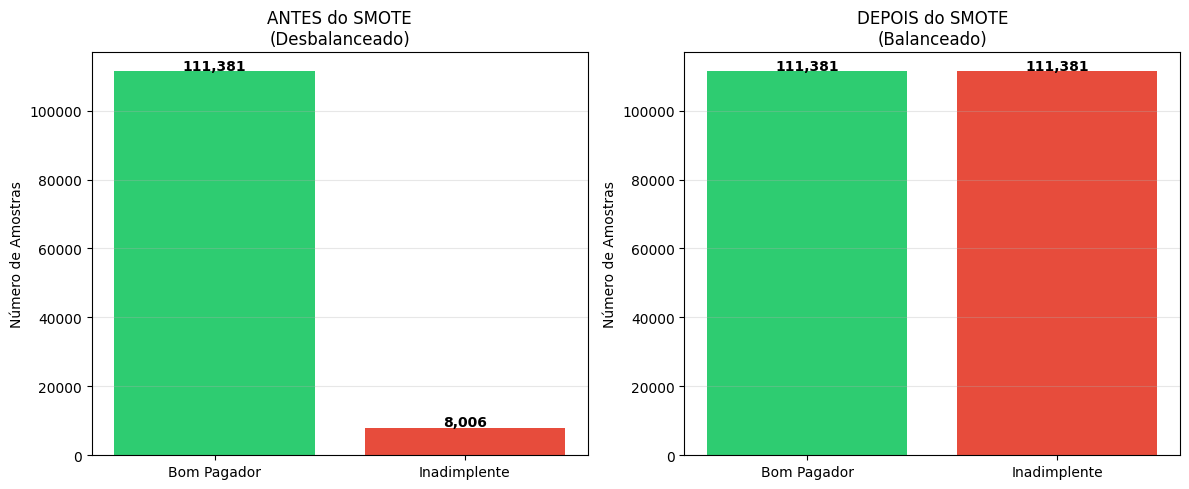


📊 Estatísticas:
   Ratio Antes:  1:13.91 (Mau:Bom)
   Ratio Depois: 1:1.00 (Mau:Bom)
   ✅ Dataset perfeitamente balanceado!


In [15]:
# Célula 5: Visualizar Efeito do SMOTE
print("\n" + "=" * 80)
print("📊 VISUALIZAÇÃO DO BALANCEAMENTO")
print("=" * 80)

# Usar versão 'no_scale' para visualização
version = 'no_scale'

y_train_before = splits[version]['y_train']
y_train_after = splits_balanced[version]['y_train']

# Contar classes
before_counts = Counter(y_train_before)
after_counts = Counter(y_train_after)

# Plotar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes do SMOTE
axes[0].bar(['Bom Pagador', 'Inadimplente'], 
           [before_counts[0], before_counts[1]],
           color=['#2ecc71', '#e74c3c'])
axes[0].set_ylabel('Número de Amostras')
axes[0].set_title('ANTES do SMOTE\n(Desbalanceado)')
axes[0].grid(axis='y', alpha=0.3)

for i, (label, count) in enumerate(before_counts.items()):
    axes[0].text(i, count + 500, f'{count:,}', ha='center', fontweight='bold')

# Depois do SMOTE
axes[1].bar(['Bom Pagador', 'Inadimplente'], 
           [after_counts[0], after_counts[1]],
           color=['#2ecc71', '#e74c3c'])
axes[1].set_ylabel('Número de Amostras')
axes[1].set_title('DEPOIS do SMOTE\n(Balanceado)')
axes[1].grid(axis='y', alpha=0.3)

for i, (label, count) in enumerate(after_counts.items()):
    axes[1].text(i, count + 500, f'{count:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Estatísticas
print(f"\n📊 Estatísticas:")
ratio_before = before_counts[1] / before_counts[0]
ratio_after = after_counts[1] / after_counts[0]

print(f"   Ratio Antes:  1:{1/ratio_before:.2f} (Mau:Bom)")
print(f"   Ratio Depois: 1:{1/ratio_after:.2f} (Mau:Bom)")
print(f"   ✅ Dataset perfeitamente balanceado!")

In [17]:
# Célula 6: Salvar Datasets Finais
print("\n" + "=" * 80)
print("💾 SALVANDO DATASETS FINAIS")
print("=" * 80)

import os
import pandas as pd

# Criar diretório para datasets finais
os.makedirs('../data/final', exist_ok=True)

# Recuperar lista de colunas originais
feature_cols = splits[list(splits.keys())[0]]['X_train'].columns

for version in splits_balanced.keys():
    print(f"\n💾 Salvando {version}...")
    
    # Datasets balanceados (para treino)
    X_train = splits_balanced[version]['X_train']
    y_train = splits_balanced[version]['y_train']
    
    # Converter para DataFrame
    train_balanced = pd.DataFrame(X_train, columns=feature_cols)
    train_balanced[target_col] = y_train
    
    filepath_train = f'../data/final/{version}_train_balanced.csv'
    train_balanced.to_csv(filepath_train, index=False)
    print(f"   ✅ Train (balanceado): {filepath_train}")
    print(f"      Shape: {train_balanced.shape}")
    
    # Datasets de teste (sempre original, sem SMOTE)
    X_test = splits_balanced[version]['X_test']
    y_test = splits_balanced[version]['y_test']
    
    test_df = pd.DataFrame(X_test, columns=feature_cols)
    test_df[target_col] = y_test
    
    filepath_test = f'../data/final/{version}_test.csv'
    test_df.to_csv(filepath_test, index=False)
    print(f"   ✅ Test (original): {filepath_test}")
    print(f"      Shape: {test_df.shape}")
    
    # Salvar também versões originais do treino (sem SMOTE) para comparação
    X_train_orig = splits[version]['X_train']
    y_train_orig = splits[version]['y_train']
    
    train_orig = X_train_orig.copy()
    train_orig[target_col] = y_train_orig.values
    
    filepath_train_orig = f'../data/final/{version}_train_original.csv'
    train_orig.to_csv(filepath_train_orig, index=False)
    print(f"   ✅ Train (original): {filepath_train_orig}")
    print(f"      Shape: {train_orig.shape}")



💾 SALVANDO DATASETS FINAIS

💾 Salvando no_scale...
   ✅ Train (balanceado): ../data/final/no_scale_train_balanced.csv
      Shape: (222762, 29)
   ✅ Test (original): ../data/final/no_scale_test.csv
      Shape: (29847, 29)
   ✅ Train (original): ../data/final/no_scale_train_original.csv
      Shape: (119387, 29)

💾 Salvando standardized...
   ✅ Train (balanceado): ../data/final/standardized_train_balanced.csv
      Shape: (222762, 29)
   ✅ Test (original): ../data/final/standardized_test.csv
      Shape: (29847, 29)
   ✅ Train (original): ../data/final/standardized_train_original.csv
      Shape: (119387, 29)

💾 Salvando normalized...
   ✅ Train (balanceado): ../data/final/normalized_train_balanced.csv
      Shape: (222762, 29)
   ✅ Test (original): ../data/final/normalized_test.csv
      Shape: (29847, 29)
   ✅ Train (original): ../data/final/normalized_train_original.csv
      Shape: (119387, 29)


In [26]:
# Célula 7: Criar Sumário dos Dados
print("\n" + "=" * 80)
print("📋 CRIANDO SUMÁRIO DOS DADOS")
print("=" * 80)

summary = []

for version in splits_balanced.keys():
    summary.append({
        'Versão': version,
        'Train_Original_Shape': splits[version]['X_train'].shape,
        'Train_Balanced_Shape': splits_balanced[version]['X_train'].shape,
        'Test_Shape': splits_balanced[version]['X_test'].shape,
        'Train_Bom_Original': (splits[version]['y_train']==0).sum(),
        'Train_Mau_Original': (splits[version]['y_train']==1).sum(),
        'Train_Bom_Balanced': (splits_balanced[version]['y_train']==0).sum(),
        'Train_Mau_Balanced': (splits_balanced[version]['y_train']==1).sum(),
        'Test_Bom': (splits_balanced[version]['y_test']==0).sum(),
        'Test_Mau': (splits_balanced[version]['y_test']==1).sum()
    })

summary_df = pd.DataFrame(summary)

print("\n📊 Sumário dos Datasets:")

print(summary_df.to_string(index=False))
# Salvar sumário
summary_df.to_csv('../reports/data_summary.csv', index=False)
print("\n✅ Sumário salvo em: reports/data_summary.csv")


📋 CRIANDO SUMÁRIO DOS DADOS

📊 Sumário dos Datasets:
      Versão Train_Original_Shape Train_Balanced_Shape  Test_Shape  Train_Bom_Original  Train_Mau_Original  Train_Bom_Balanced  Train_Mau_Balanced  Test_Bom  Test_Mau
    no_scale         (119387, 28)         (222762, 28) (29847, 28)              111381                8006              111381              111381     27845      2002
standardized         (119387, 28)         (222762, 28) (29847, 28)              111381                8006              111381              111381     27845      2002
  normalized         (119387, 28)         (222762, 28) (29847, 28)              111381                8006              111381              111381     27845      2002

✅ Sumário salvo em: reports/data_summary.csv


In [24]:
# Célula 8: Documentar Processo
print("\n" + "=" * 80)
print("📝 DOCUMENTANDO PROCESSO")
print("=" * 80)

documentation = f"""
{'='*80}
PREPARAÇÃO FINAL DOS DADOS - DOCUMENTAÇÃO
{'='*80}

Data: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

{'='*80}
1. TRAIN/TEST SPLIT
{'='*80}

Configuração:
- Test Size: {test_size*100:.0f}%
- Random State: {random_state}
- Stratified: Sim

Distribuição Original:
{summary_df.to_string(index=False)}

{'='*80}
2. BALANCEAMENTO (SMOTE)
{'='*80}

Método: SMOTE (Synthetic Minority Over-sampling Technique)
Aplicado: Apenas no conjunto de TREINO
Motivo: Evitar data leakage

Resultado:
- Classes perfeitamente balanceadas (50/50)
- Aumento sintético da classe minoritária (inadimplentes)

{'='*80}
3. ARQUIVOS GERADOS
{'='*80}

Para cada versão (no_scale, standardized, normalized):

1. [versão]_train_original.csv   - Treino desbalanceado (original)
2. [versão]_train_balanced.csv   - Treino balanceado (com SMOTE)
3. [versão]_test.csv             - Teste (sempre original)

Uso Recomendado:
- Treinar modelos: usar train_balanced
- Avaliar modelos: usar test (sempre!)
- Comparações: usar train_original se necessário

{'='*80}
4. PRÓXIMOS PASSOS
{'='*80}

✅ PRONTO PARA MODELAGEM!

Modelos Sugeridos:
1. Logistic Regression (baseline) → usar standardized
2. Random Forest              → usar no_scale
3. XGBoost/LightGBM          → usar no_scale
4. Neural Network            → usar normalized

Métricas de Avaliação:
- AUC-ROC
- Precision/Recall
- F1-Score
- Confusion Matrix
- KS Statistic

{'='*80}
"""

with open('../reports/final_preparation_doc.txt', 'w', encoding='utf-8') as f:
    f.write(documentation)

print("✅ Documentação salva em: reports/final_preparation_doc.txt")
print("\n" + documentation)


📝 DOCUMENTANDO PROCESSO
✅ Documentação salva em: reports/final_preparation_doc.txt


PREPARAÇÃO FINAL DOS DADOS - DOCUMENTAÇÃO

Data: 2026-03-02 16:38:10

1. TRAIN/TEST SPLIT

Configuração:
- Test Size: 20%
- Random State: 42
- Stratified: Sim

Distribuição Original:
      Versão Train_Original_Shape Train_Balanced_Shape  Test_Shape  Train_Bom_Original  Train_Mau_Original  Train_Bom_Balanced  Train_Mau_Balanced  Test_Bom  Test_Mau
    no_scale         (119387, 28)         (222762, 28) (29847, 28)              111381                8006              111381              111381     27845      2002
standardized         (119387, 28)         (222762, 28) (29847, 28)              111381                8006              111381              111381     27845      2002
  normalized         (119387, 28)         (222762, 28) (29847, 28)              111381                8006              111381              111381     27845      2002

2. BALANCEAMENTO (SMOTE)

Método: SMOTE (Synthetic Minority Ov

In [28]:
# Célula 9: Checkpoint Final
print("\n" + "=" * 80)
print("🎉 SEMANA 3 COMPLETA!")
print("=" * 80)

# Recuperar lista de colunas originais
feature_cols = splits['no_scale']['X_train'].columns

print(f"\n✅ CONQUISTAS DA SEMANA 3:")
print(f"   • Feature Engineering: {datasets['no_scale'].shape[1]-1} features criadas")
print(f"   • Encoding: Categóricas transformadas")
print(f"   • Scaling: 3 versões diferentes")
print(f"   • Seleção: ~{len(feature_cols)} features mantidas")
print(f"   • Split: Train/Test dividido (80/20)")
print(f"   • Balanceamento: SMOTE aplicado")

print(f"\n📊 DATASETS FINAIS:")
for version in ['no_scale', 'standardized', 'normalized']:
    print(f"\n   {version}:")
    print(f"      Train (balanced): {splits_balanced[version]['X_train'].shape}")
    print(f"      Test:             {splits_balanced[version]['X_test'].shape}")

print(f"\n🎯 SEMANA 4 (Próxima):")
print(f"   • Dia 16: Baseline Model (Logistic Regression)")
print(f"   • Dia 17: Random Forest")
print(f"   • Dia 18: XGBoost/LightGBM")
print(f"   • Dia 19: Otimização de Hiperparâmetros")
print(f"   • Dia 20: Avaliação e Comparação Final")

print(f"\n PRONTO PARA MODELAGEM!")



🎉 SEMANA 3 COMPLETA!

✅ CONQUISTAS DA SEMANA 3:
   • Feature Engineering: 28 features criadas
   • Encoding: Categóricas transformadas
   • Scaling: 3 versões diferentes
   • Seleção: ~28 features mantidas
   • Split: Train/Test dividido (80/20)
   • Balanceamento: SMOTE aplicado

📊 DATASETS FINAIS:

   no_scale:
      Train (balanced): (222762, 28)
      Test:             (29847, 28)

   standardized:
      Train (balanced): (222762, 28)
      Test:             (29847, 28)

   normalized:
      Train (balanced): (222762, 28)
      Test:             (29847, 28)

🎯 SEMANA 4 (Próxima):
   • Dia 16: Baseline Model (Logistic Regression)
   • Dia 17: Random Forest
   • Dia 18: XGBoost/LightGBM
   • Dia 19: Otimização de Hiperparâmetros
   • Dia 20: Avaliação e Comparação Final

 PRONTO PARA MODELAGEM!
